In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
df=pd.read_csv("smartcart_customers.csv")

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
df.shape

(2240, 22)

In [5]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

## Data Preprocessing

### 1. Handle the missing values 

In [6]:
df["Income"]= df["Income"].fillna(df["Income"].median())

## Feature Engineering 

In [7]:
# Date 
# Year_Birth and Dt_Customer(joining date) 
# convert Year_Birth into age 
# convert Dt_Customer into customer tenure days -- max date has tenur 0 and then minus that 

In [8]:
# Age 
df["Age"]= 2026- df["Year_Birth"] 

In [9]:
# cutomer tenure days 
df["Dt_Customer"]= pd.to_datetime(df["Dt_Customer"],dayfirst=True)

reference_date=df["Dt_Customer"].max()

df["Customer_Tenure_Days"]= (reference_date- df["Dt_Customer"]).dt.days

In [10]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [11]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days'],
      dtype='object')

In [12]:
# Spending 

df["Total_Spending"] = df["MntWines"] + df["MntFruits"]+df["MntMeatProducts"]+df["MntFishProducts"]+df["MntSweetProducts"]+df["MntGoldProds"]

In [13]:
# children 
df["Total_Children"] =df["Kidhome"]+df["Teenhome"]

In [14]:
#Education 
df["Education"].value_counts()

# divide onto 3 categories - undergraduate, graduate, postgraduate 
df["Education"]= df["Education"].replace({
    "Basic":"Undergraduate", 
    "2n Cycle":"Undergraduate", 
    "Graduation":"Graduate", 
    "PhD":"Postgraduate",
    "Master":"Postgraduate"
})

In [15]:
df["Education"].value_counts()

Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

In [16]:
# Marital Status 
df["Marital_Status"].value_counts()

df["Living_With"]=df["Marital_Status"].replace({
    "Together":"Partner",
    "Married":"Partner",
    "Single":"Alone",
    "Divorced":"Alone", 
    "Widow":"Alone", 
    "Alone":"Alone",  
    "Absurd":"Alone", 
    "YOLO":"Alone",
})

In [17]:
df["Living_With"].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

### 2. Drop Columns

In [18]:
df.columns 

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days', 'Total_Spending',
       'Total_Children', 'Living_With'],
      dtype='object')

In [19]:
cols=["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]
spending=["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]

cols_to_drop=cols+spending

df_cleaned=df.drop(columns=cols_to_drop)

In [20]:
df_cleaned.shape

(2240, 15)

### Outliers 

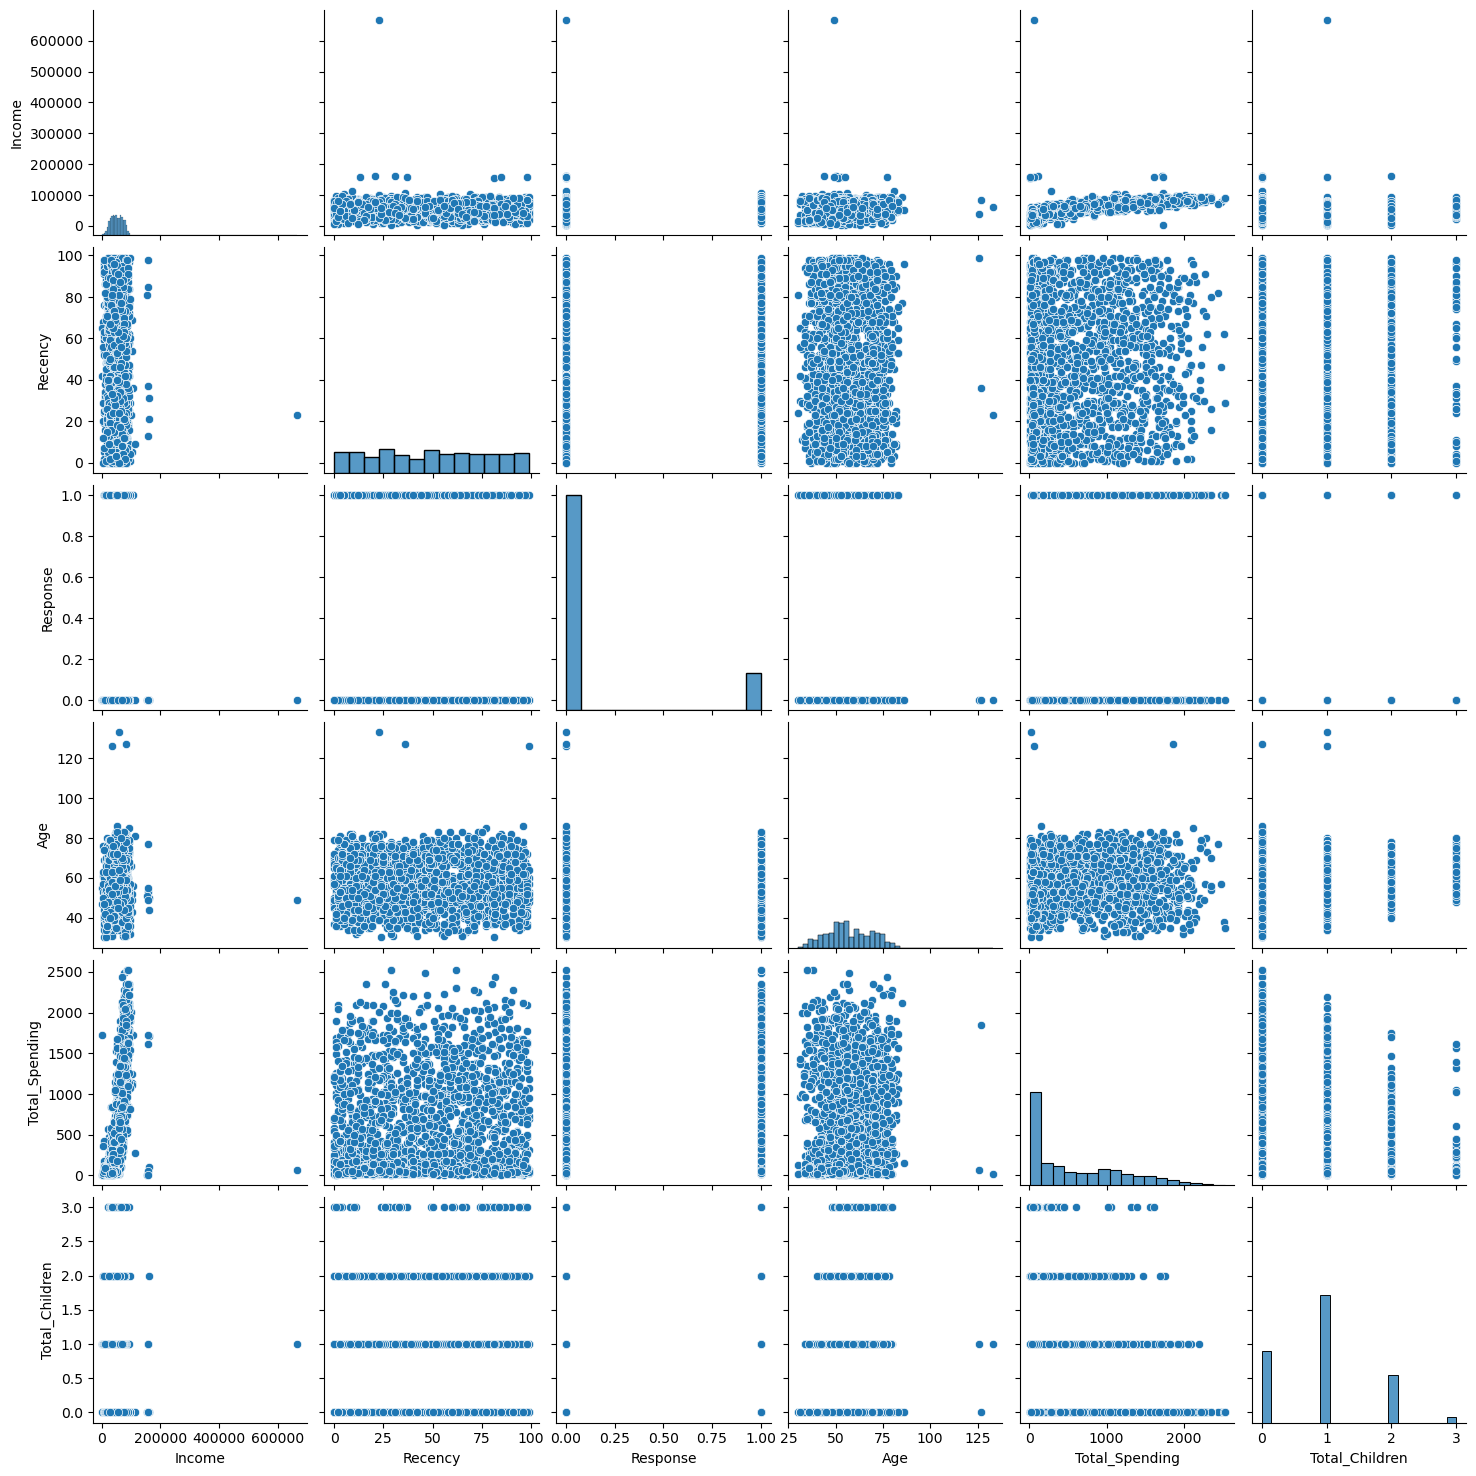

In [21]:
cols=["Income","Recency","Response","Age","Total_Spending","Total_Children"] 

# relative plots of some features - pair plots 
sns.pairplot(df_cleaned[cols])

In [22]:
# in Income there is one point that is an outlier in all 5 plots 
# the income point to remove is 600000 

# Age points have 120+ is outlier ie remove all above age<90

In [23]:
# Remove outliers 
print("Data size with outliers:", len(df_cleaned)) 

df_cleaned= df_cleaned[df_cleaned["Age"]<90]
df_cleaned=df_cleaned[df_cleaned["Income"]<600000] 

print("Data without the outliers:", len(df_cleaned))

Data size with outliers: 2240
Data without the outliers: 2236


## Heatmap 

In [24]:
corr=df_cleaned.corr(numeric_only=True)  

<Axes: >

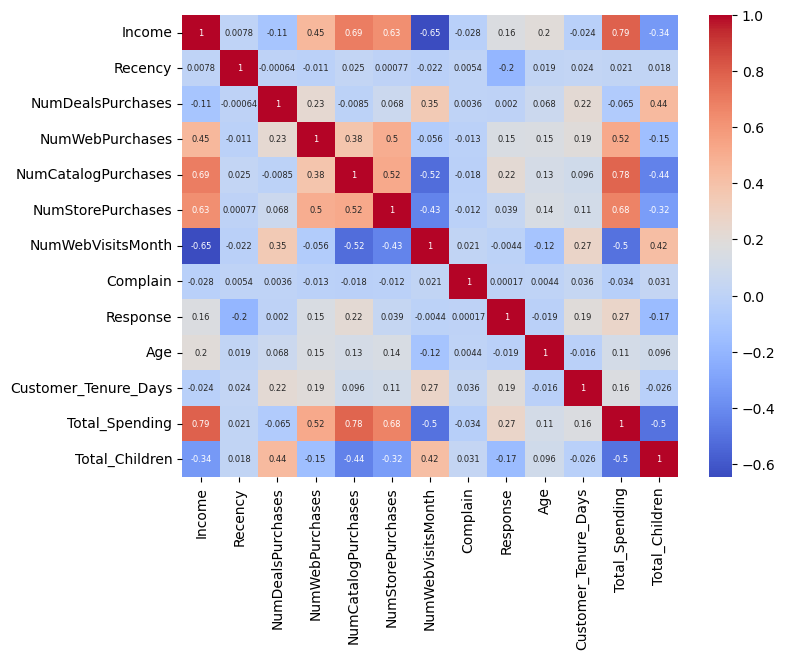

In [25]:
plt.figure(figsize=(8,6)) 
sns.heatmap(
    corr, 
    annot=True, 
    annot_kws={"size":6}, 
    cmap= "coolwarm"
)

## Encoding

In [26]:
from sklearn.preprocessing import OneHotEncoder 

ohe=OneHotEncoder() 
cat_col=["Education","Living_With"] 
enc_col=ohe.fit_transform(df_cleaned[cat_col]) 

In [27]:
# convert encoded columns into dataframes 

enc_df=pd.DataFrame(enc_col.toarray(), columns=ohe.get_feature_names_out(cat_col),index=df_cleaned.index)

In [28]:
df_encoded=pd.concat([df_cleaned.drop(columns=cat_col),enc_df],axis=1)

In [29]:
df_encoded.shape

(2236, 18)

## Scaling

In [30]:
from sklearn.preprocessing import StandardScaler 

X=df_encoded

scaler=StandardScaler() 
X_scaled=scaler.fit_transform(X)

## Visualization 

In [31]:
X_scaled.shape

(2236, 18)

In [32]:
# PCA 

# 2D 
from sklearn.decomposition import PCA

pca= PCA(n_components=2) 
X_pca=pca.fit_transform(X_scaled)

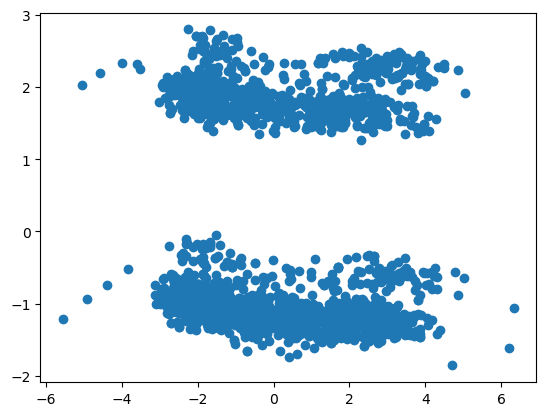

In [33]:
# plot
plt.scatter(X_pca[:,0],X_pca[:,1])

In [34]:
pca.explained_variance_ratio_
# 23+11= 34% variance is captured in 2D 

array([0.23163158, 0.11385454])

In [35]:
# 3D 
pca= PCA(n_components=3) 
X_pca=pca.fit_transform(X_scaled) 

pca.explained_variance_ratio_ 
# 23+11+10= 44% variance is captured in 3D 

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3D Projection')

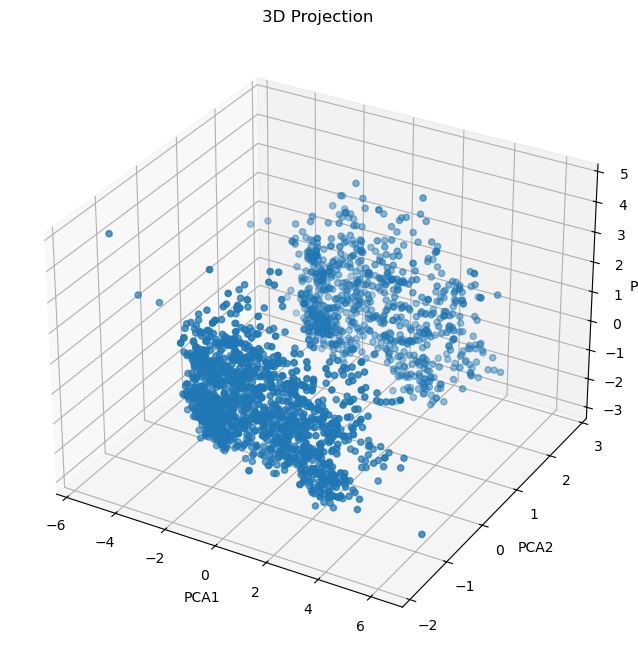

In [36]:
fig=plt.figure(figsize=(10,8)) 

ax=fig.add_subplot(111, projection="3d") 

ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2") 
ax.set_zlabel("PCA3") 
ax.set_title("3D Projection")

## Analyze K value

### 1. Elbow Method

In [37]:
from sklearn.cluster import KMeans 
from kneed import KneeLocator 

wcss=[]
for k in range(1,11): 
    kmeans=KMeans(n_clusters=k, random_state=42) 
    kmeans.fit_transform(X_pca) 
    wcss.append(kmeans.inertia_) 
    

In [38]:
knee= KneeLocator(range(1,11), wcss, curve="convex", direction="decreasing")
optimal_k=knee.elbow

In [39]:
print("Best k=", optimal_k)

Best k= 4


Text(0, 0.5, 'WCSS')

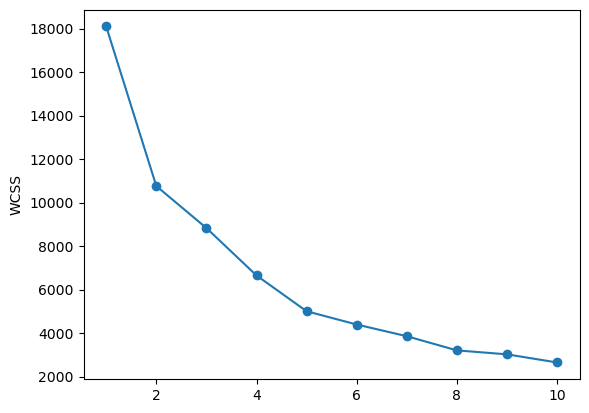

In [40]:
plt.plot(range(1,11), wcss, marker='o') 
plt.xlabel=("K") 
plt.ylabel("WCSS")

### 2. Silhouette Score

Text(0, 0.5, 'Silhouette score')

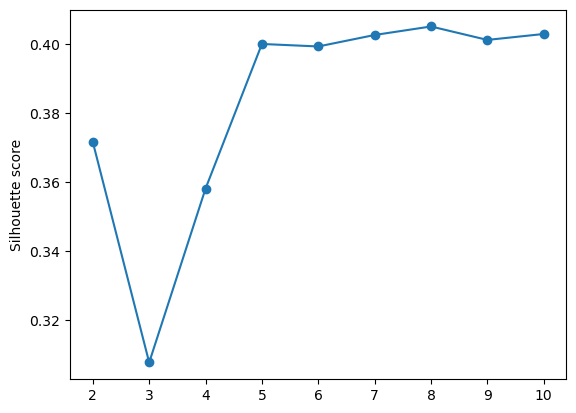

In [41]:
from sklearn.metrics import silhouette_score 
scores=[] 
for k in range(2,11): 
    kmeans=KMeans(n_clusters=k, random_state=42) 
    labels=kmeans.fit_predict(X_pca) 
    score= silhouette_score(X_pca, labels)
    scores.append(score) 

plt.plot(range(2,11), scores, marker='o') 
plt.xlabel=("K") 
plt.ylabel("Silhouette score")

Text(0, 0.5, 'Silhoute score')

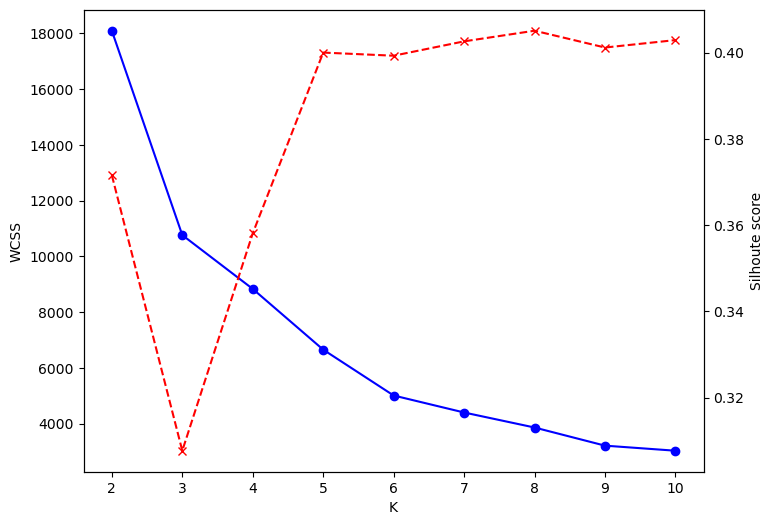

In [42]:
# Combined plot 

k_range=range(2,11) 
fig,ax1=plt.subplots(figsize=(8,6))
ax1.plot(k_range, wcss[:len(k_range)],marker='o',color="blue")
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2=ax1.twinx() 
ax2.plot(k_range,scores[:len(k_range)],marker='x',color="red",linestyle="--") 
ax2.set_ylabel("Silhoute score")

### Clustering

In [43]:
# KMeans 

kmeans= KMeans(n_clusters=4,random_state=42) 
labels_kmeans=kmeans.fit_predict(X_pca) 

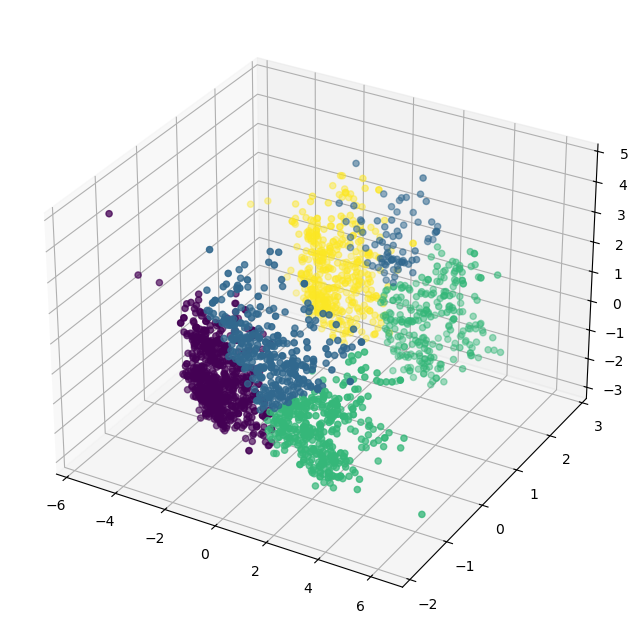

In [44]:
fig=plt.figure(figsize=(10,8)) 
ax=fig.add_subplot(111, projection="3d") 
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_kmeans)

In [45]:
# Agglomerative Clustering 

from sklearn.cluster import AgglomerativeClustering 
agg_clf=AgglomerativeClustering(n_clusters=4, linkage="ward") 
labels_agg= agg_clf.fit_predict(X_pca)

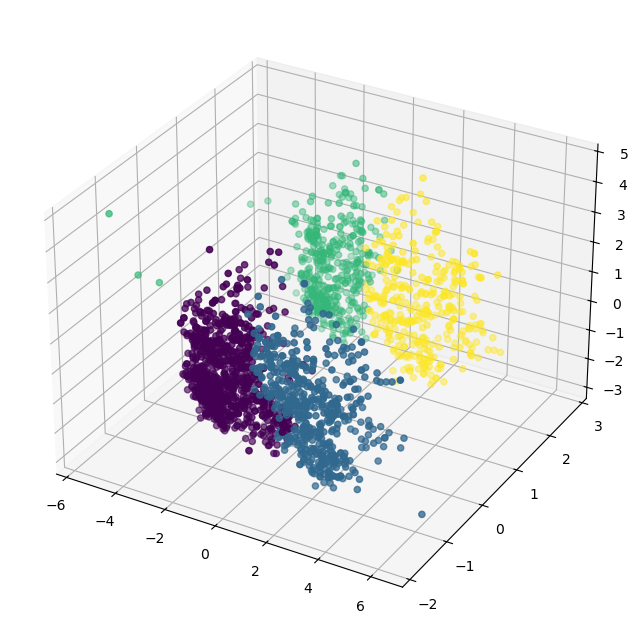

In [46]:
fig=plt.figure(figsize=(10,8)) 
ax=fig.add_subplot(111, projection="3d") 
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_agg)

In [47]:
# use agglomerative clustering as better 4 clusters 

### Charecterization of clusters

In [48]:
X["cluster"]=labels_agg

In [49]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='cluster', ylabel='count'>

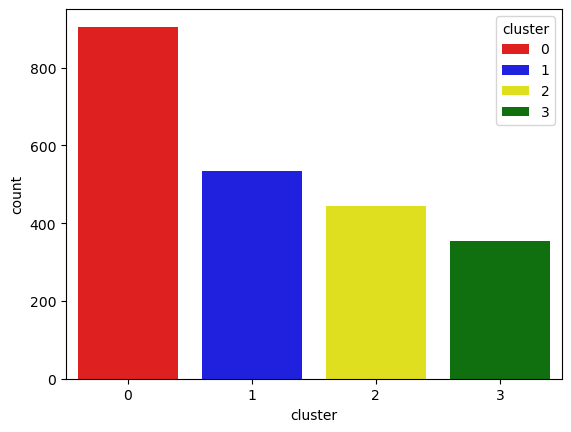

In [50]:
pal=["red","blue","yellow","green"] 
sns.countplot(x=X["cluster"],palette=pal, hue=X["cluster"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

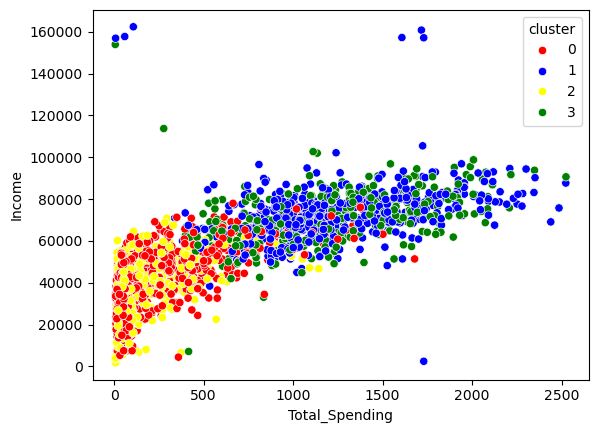

In [51]:
# Income and Spending Patterns 
sns.scatterplot(x=X["Total_Spending"], y=X["Income"], hue=X["cluster"],palette=pal)

In [52]:
# cluter 0 : red 
# low/ income, low/moderate spending

# cluter 1 : blue 
# high income, high spending

# cluter 2 : yellow 
# low income, low spending 

# cluter 3 : green 
# moderate/high income, high spending

### Cluster Summary 

In [53]:
cluster_summary= X.groupby('cluster').mean() 
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        Age  Customer_Tenure_Days  Total_Spending  \
cluster         